
Training with RandomNormal Initialization
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7991 - loss: 0.7865 - val_accuracy: 0.9366 - val_loss: 0.2133
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9438 - loss: 0.1970 - val_accuracy: 0.9566 - val_loss: 0.1369
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9634 - loss: 0.1298 - val_accuracy: 0.9663 - val_loss: 0.1085
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9727 - loss: 0.0962 - val_accuracy: 0.9713 - val_loss: 0.0948
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9789 - loss: 0.0751 - val_accuracy: 0.9728 - val_loss: 0.0877
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0599 - val_accuracy: 0.9740 - val_loss: 0.0847
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0485 - val_accuracy: 0.9736 - val_loss: 0.0856
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

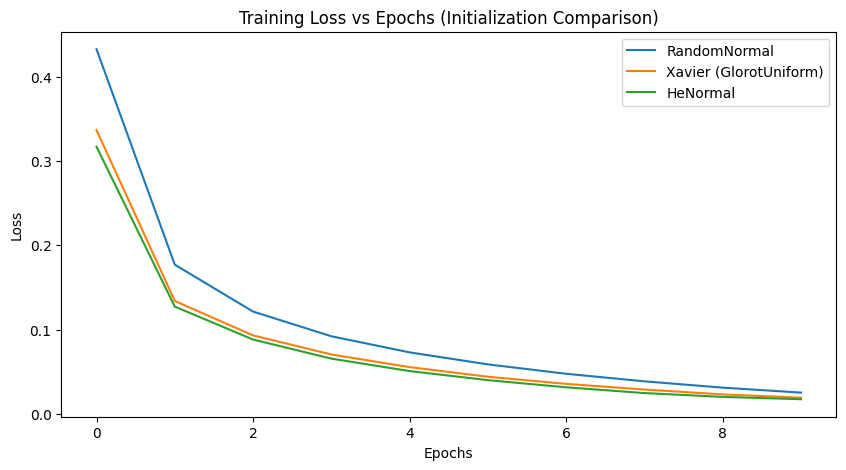

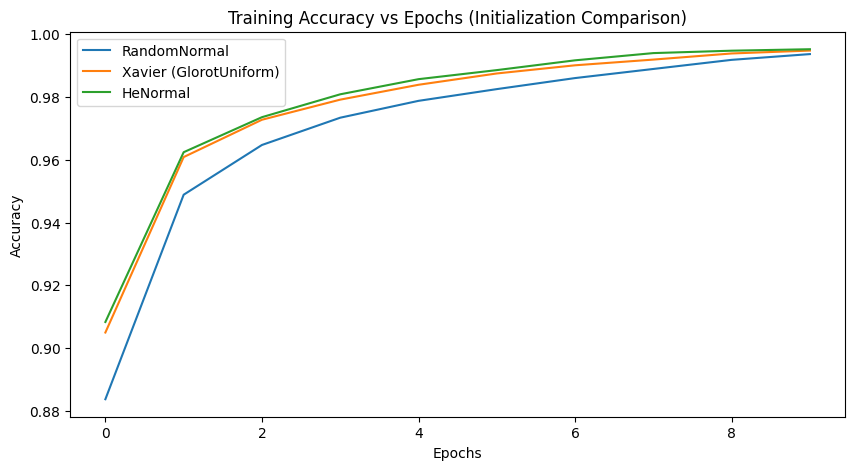

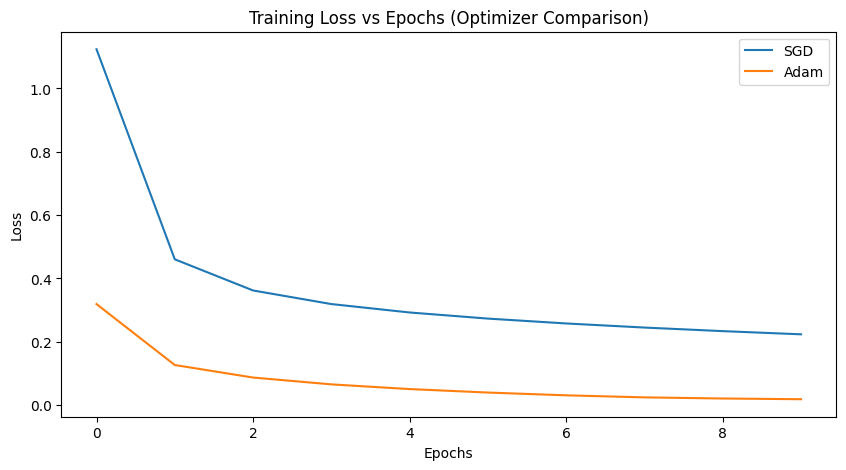

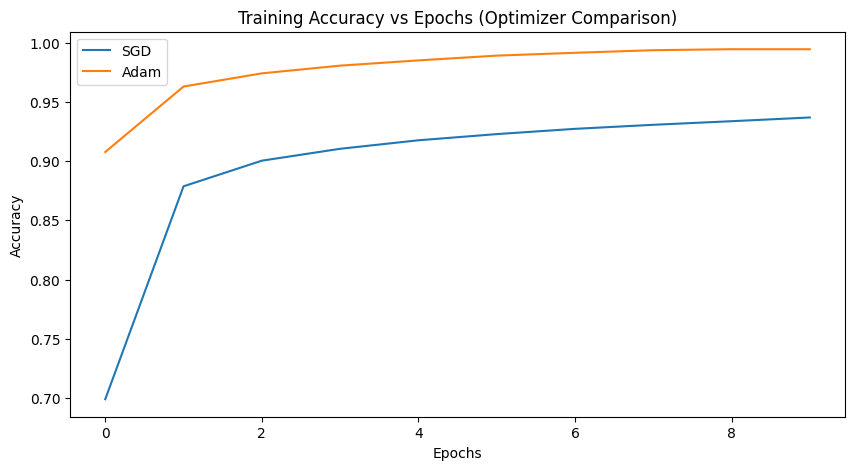

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def create_mlp(initializer):
    model = Sequential()

    model.add(Dense(128, activation='relu',
                    kernel_initializer=initializer,
                    input_shape=(784,)))

    model.add(Dense(64, activation='relu',
                    kernel_initializer=initializer))

    model.add(Dense(10, activation='softmax',
                    kernel_initializer=initializer))

    return model

initializers = {
    "RandomNormal": tf.keras.initializers.RandomNormal(),
    "Xavier (GlorotUniform)": tf.keras.initializers.GlorotUniform(),
    "HeNormal": tf.keras.initializers.HeNormal()
}

history_init = {}

for name, init in initializers.items():
    print(f"\nTraining with {name} Initialization")

    model = create_mlp(init)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    history_init[name] = history

optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.001)
}

history_opt = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name} Optimizer")

    model = create_mlp(tf.keras.initializers.HeNormal())

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    history_opt[name] = history


plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
for name, history in history_opt.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
for name, history in history_opt.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
